In [ ]:
! pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers , Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , MinMaxScaler

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("/content/donnees_synthetiques_tollxpress_benin_2023-2024.csv")

In [ ]:
df.columns

Index(['ID_transaction', 'Date_Heure', 'Gare', 'Voie', 'Classe_vehicule',
       'Montant_paye', 'Type_paiement', 'Statut_abonnement',
       'Type_transaction', 'Date', 'Heure', 'Jour_semaine', 'Mois', 'Annee',
       'Montant_net', 'Periode_Jour', 'CA'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219283 entries, 0 to 219282
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ID_transaction     219283 non-null  int64  
 1   Date_Heure         219283 non-null  object 
 2   Gare               219283 non-null  object 
 3   Voie               219283 non-null  int64  
 4   Classe_vehicule    219283 non-null  object 
 5   Montant_paye       219283 non-null  float64
 6   Type_paiement      219283 non-null  object 
 7   Statut_abonnement  219283 non-null  object 
 8   Type_transaction   219283 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 15.1+ MB


In [ ]:
descripion=df.describe()
descripion

,ID_transaction,Voie,Montant_paye
count,219283.000000,219283.000000,219283.000000
mean,109642.000000,2.668985,917.820237
std,63301.693877,1.376175,2784.813808
min,1.000000,1.000000,-1998.000000
25%,54821.500000,2.000000,300.000000
50%,109642.000000,3.000000,400.000000
75%,164462.500000,4.000000,700.000000
max,219283.000000,6.000000,49981.000000


=== Chargement des données ===
Dimension du dataset : 219,283 lignes × 9 colonnes
Période : 2023-01-01 01:34:11 → 2024-12-31 22:57:24

=== Aperçu des données après prétraitement ===


,ID_transaction,Date_Heure,Gare,Voie,Classe_vehicule,Montant_paye,Type_paiement,Statut_abonnement,Type_transaction,Date,Heure,Jour_semaine,Mois,Annee,Montant_net,Periode_Jour
0,1,2023-01-01 01:34:11,Houegbo,1,MOTO,200.00,Abonne,Oui,Abonnement,2023-01-01,1,Sunday,January,2023,200.00,Nuit
1,2,2023-01-01 01:47:43,Epke,1,VL,650.00,Especes,Non,Standard,2023-01-01,1,Sunday,January,2023,650.00,Nuit
2,3,2023-01-01 05:18:01,Cotonou-Nord,1,VL,550.00,Abonne,Non,Standard,2023-01-01,5,Sunday,January,2023,550.00,Nuit
3,4,2023-01-01 06:00:50,Porto-Novo,2,MOTO,450.00,Especes,Non,Standard,2023-01-01,6,Sunday,January,2023,450.00,Matin
4,5,2023-01-01 06:11:36,Parakou,1,MOTO,300.00,Especes,Non,Standard,2023-01-01,6,Sunday,January,2023,300.00,Matin



ANALYSE UNIVARIÉE

Statistiques descriptives - Montant_paye :
count   219283.00
mean       917.82
std       2784.81
min      -1998.00
25%        300.00
50%        400.00
75%        700.00
max      49981.00
Name: Montant_paye, dtype: float64


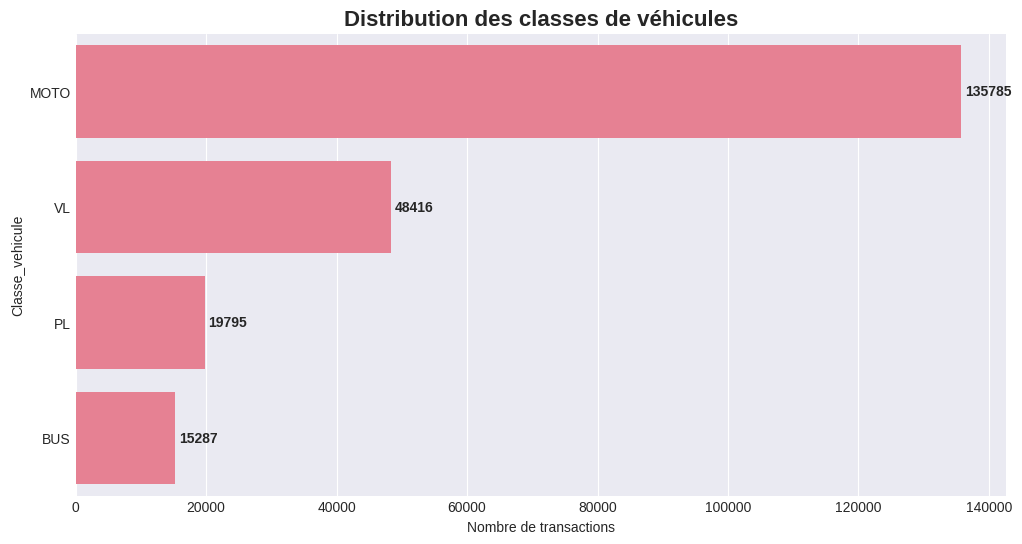

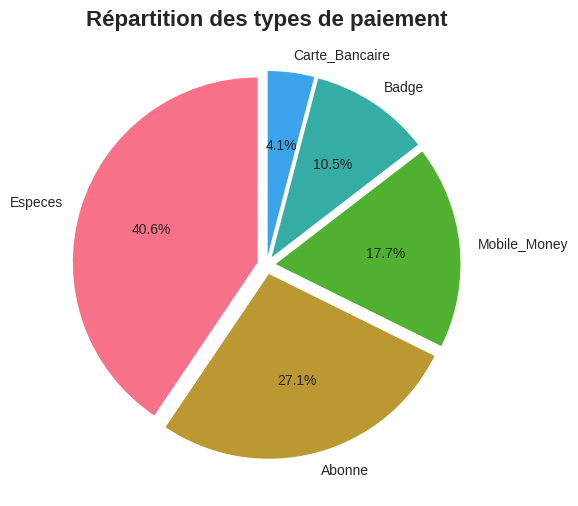


ANALYSE TEMPORELLE ET PAR GARE


<Figure size 1400x700 with 0 Axes>

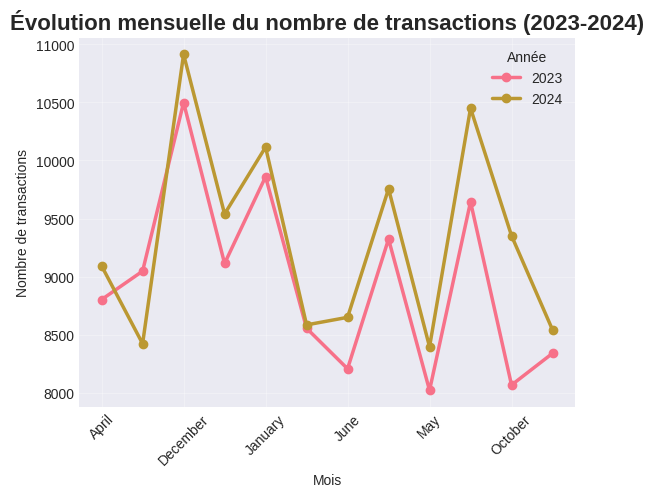

<Figure size 1400x700 with 0 Axes>

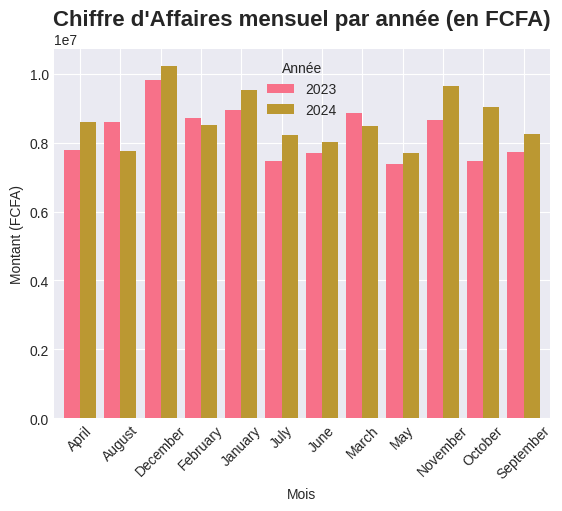

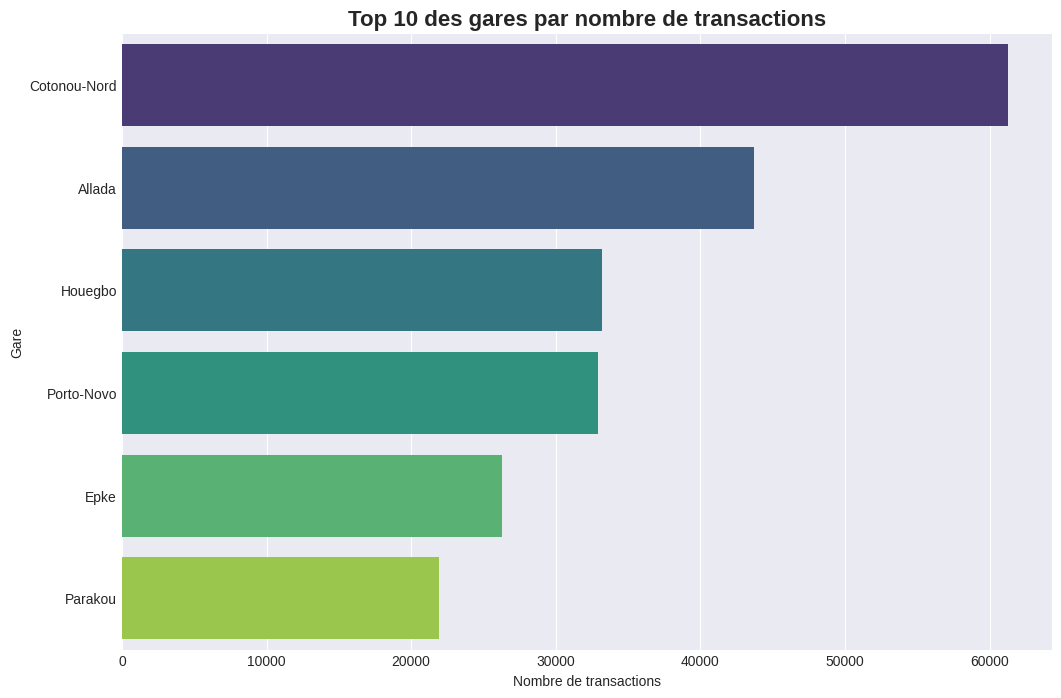

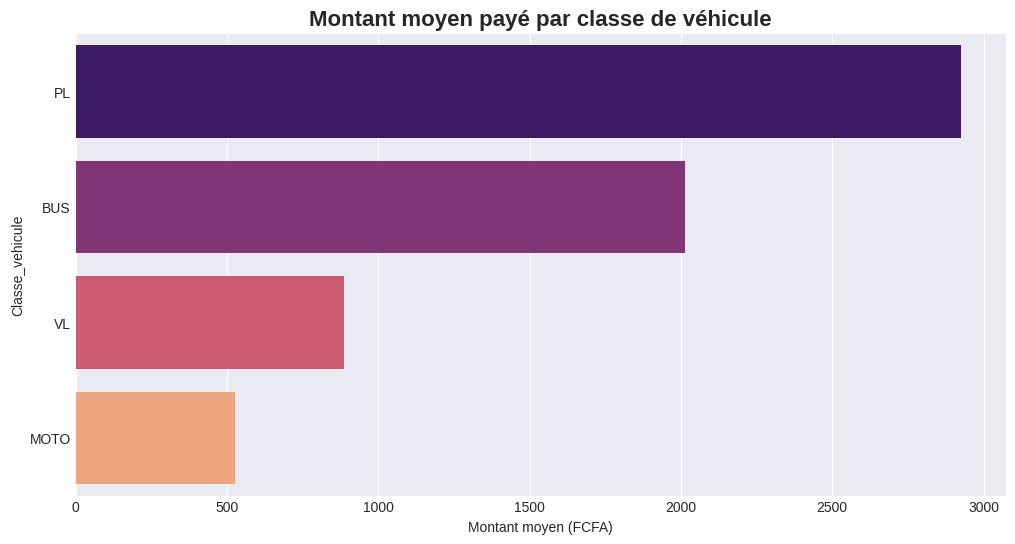


DÉTECTION D'ANOMALIES
Nombre de transactions avec montant ≤ 0 : 3534 (1.61%)


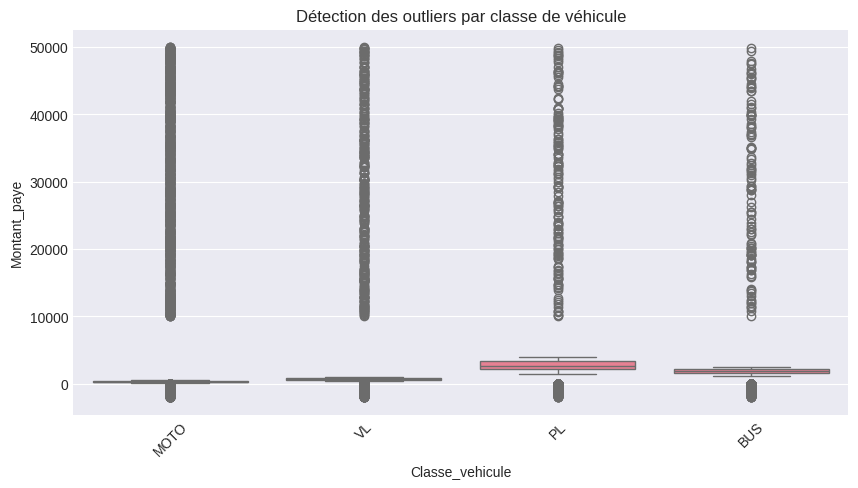


ANALYSE MULTIVARIÉE


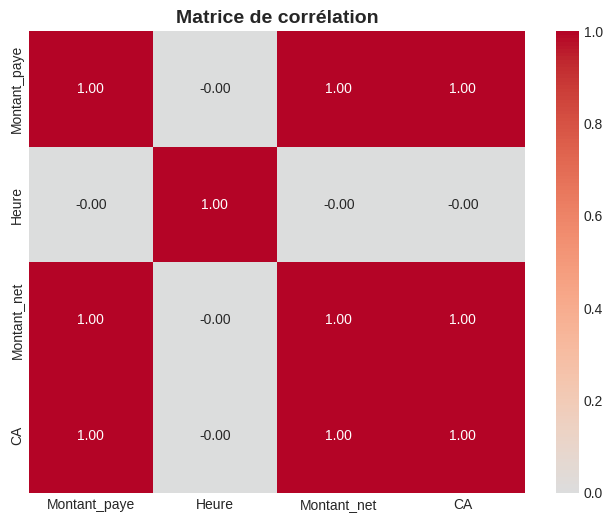

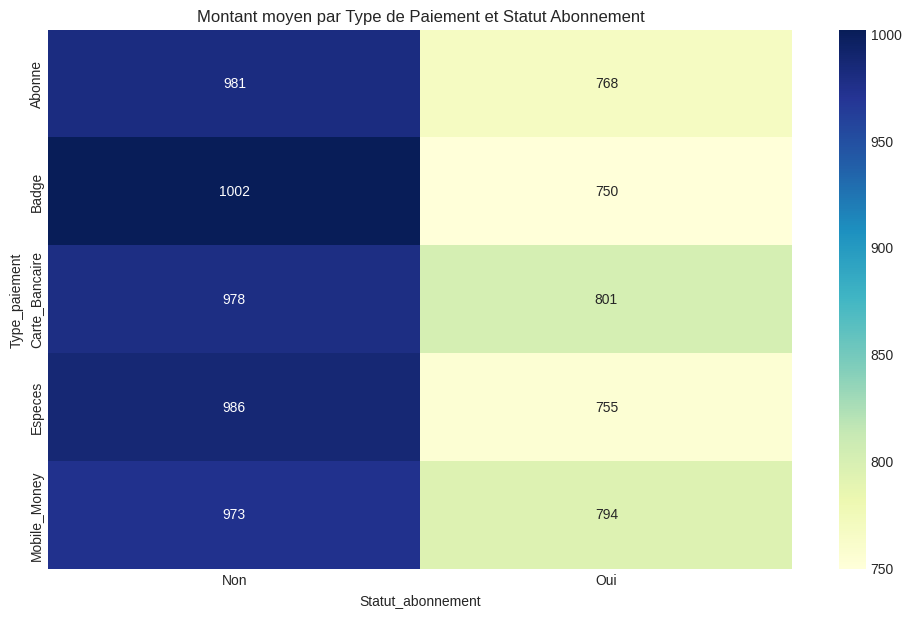


RÉSUMÉ DES INSIGHTS CLÉS
Nombre total de transactions          : 219,283
Chiffre d'affaires total              : 202,970,655 FCFA
Montant moyen par transaction        : 926 FCFA
Pourcentage d'abonnés                 : 27.1%
Pourcentage de transactions Standard  : 56.4%
Nombre de transactions Exonérées      : 8598

Top 3 gares par Chiffre d'Affaires :
Gare
Cotonou-Nord   56943948.00
Allada         39357020.00
Porto-Novo     30951631.00
Name: Montant_net, dtype: float64

EDA terminé avec succès !


In [ ]:
# ====================== CONFIGURATION ======================
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ====================== 1. CHARGEMENT DES DONNÉES ======================
print("=== Chargement des données ===")
df = pd.read_csv('donnees_synthetiques_tollxpress_benin_2023-2024.csv')

print(f"Dimension du dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Période : {df['Date_Heure'].min()} → {df['Date_Heure'].max()}")

# ====================== 2. PRÉTRAITEMENT ======================
# Conversion de la date
df['Date_Heure'] = pd.to_datetime(df['Date_Heure'])
df['Date'] = df['Date_Heure'].dt.date
df['Heure'] = df['Date_Heure'].dt.hour
df['Jour_semaine'] = df['Date_Heure'].dt.day_name()
df['Mois'] = df['Date_Heure'].dt.month_name()
df['Annee'] = df['Date_Heure'].dt.year

# Nettoyage du montant (valeurs négatives = anomalies ou remboursements)
df['Montant_paye'] = pd.to_numeric(df['Montant_paye'], errors='coerce')
df['Montant_net'] = df['Montant_paye'].clip(lower=0)  # On garde les positifs pour les stats business

# Création de catégories temporelles
df['Periode_Jour'] = pd.cut(df['Heure'],
                            bins=[0,6,12,18,24],
                            labels=['Nuit', 'Matin', 'Après-midi', 'Soir'],
                            right=False)

print("\n=== Aperçu des données après prétraitement ===")
display(df.head())

# ====================== 3. ANALYSE UNIVARIÉE ======================
print("\n" + "="*60)
print("ANALYSE UNIVARIÉE")
print("="*60)

# Statistiques descriptives générales
print("\nStatistiques descriptives - Montant_paye :")
print(df['Montant_paye'].describe())

# Distribution des classes de véhicules
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, y='Classe_vehicule', order=df['Classe_vehicule'].value_counts().index)
plt.title('Distribution des classes de véhicules', fontsize=16, fontweight='bold')
plt.xlabel('Nombre de transactions')
for i, v in enumerate(df['Classe_vehicule'].value_counts()):
    ax.text(v + 500, i, str(v), va='center', fontweight='bold')
plt.show()

# Répartition par type de paiement
plt.figure(figsize=(10, 6))
df['Type_paiement'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90,
                                       explode=[0.05]*len(df['Type_paiement'].unique()))
plt.title('Répartition des types de paiement', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.show()

# ====================== 4. ANALYSE BIVARIÉE & TEMPORELLE ======================
print("\n" + "="*60)
print("ANALYSE TEMPORELLE ET PAR GARE")
print("="*60)

# Évolution du nombre de transactions par mois
plt.figure(figsize=(14, 7))
monthly = df.groupby(['Annee', 'Mois']).size().unstack(0)
monthly.plot(kind='line', marker='o', linewidth=2.5)
plt.title('Évolution mensuelle du nombre de transactions (2023-2024)', fontsize=16, fontweight='bold')
plt.ylabel('Nombre de transactions')
plt.xticks(rotation=45)
plt.legend(title='Année')
plt.grid(True, alpha=0.3)
plt.show()

# Chiffre d'affaires par mois
df['CA'] = df['Montant_net']
ca_mensuel = df.groupby(['Annee', 'Mois'])['CA'].sum().unstack(0)

plt.figure(figsize=(14, 7))
ca_mensuel.plot(kind='bar', width=0.8)
plt.title("Chiffre d'Affaires mensuel par année (en FCFA)", fontsize=16, fontweight='bold')
plt.ylabel('Montant (FCFA)')
plt.xticks(rotation=45)
plt.legend(title='Année')
plt.show()

# Transactions par gare (Top 10)
plt.figure(figsize=(12, 8))
top_gares = df['Gare'].value_counts().head(10)
sns.barplot(x=top_gares.values, y=top_gares.index, palette='viridis')
plt.title('Top 10 des gares par nombre de transactions', fontsize=16, fontweight='bold')
plt.xlabel('Nombre de transactions')
plt.show()

# Montant moyen par classe de véhicule
plt.figure(figsize=(12, 6))
mean_by_class = df.groupby('Classe_vehicule')['Montant_net'].mean().sort_values(ascending=False)
sns.barplot(x=mean_by_class.values, y=mean_by_class.index, palette='magma')
plt.title('Montant moyen payé par classe de véhicule', fontsize=16, fontweight='bold')
plt.xlabel('Montant moyen (FCFA)')
plt.show()

# ====================== 5. ANALYSE DES ANOMALIES ======================
print("\n" + "="*60)
print("DÉTECTION D'ANOMALIES")
print("="*60)

# Transactions avec montant négatif ou nul
anomalies = df[df['Montant_paye'] <= 0]
print(f"Nombre de transactions avec montant ≤ 0 : {len(anomalies)} ({len(anomalies)/len(df)*100:.2f}%)")

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Classe_vehicule', y='Montant_paye')
plt.title('Détection des outliers par classe de véhicule')
plt.xticks(rotation=45)
plt.show()

# ====================== 6. ANALYSE MULTIVARIÉE ======================
print("\n" + "="*60)
print("ANALYSE MULTIVARIÉE")
print("="*60)

# Heatmap de corrélation (variables numériques)
numeric_cols = ['Montant_paye', 'Heure', 'Montant_net', 'CA']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de corrélation', fontsize=14, fontweight='bold')
plt.show()

# Montant moyen par type de paiement et abonnement
pivot = df.pivot_table(values='Montant_net',
                       index='Type_paiement',
                       columns='Statut_abonnement',
                       aggfunc='mean')

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Montant moyen par Type de Paiement et Statut Abonnement')
plt.show()

# ====================== 7. RAPPORT SYNTHÉTIQUE ======================
print("\n" + "="*80)
print("RÉSUMÉ DES INSIGHTS CLÉS")
print("="*80)

total_transactions = len(df)
total_ca = df['Montant_net'].sum()
ca_moyen = df['Montant_net'].mean()

print(f"Nombre total de transactions          : {total_transactions:,}")
print(f"Chiffre d'affaires total              : {total_ca:,.0f} FCFA")
print(f"Montant moyen par transaction        : {ca_moyen:,.0f} FCFA")
print(f"Pourcentage d'abonnés                 : {df['Statut_abonnement'].value_counts(normalize=True).get('Oui', 0)*100:.1f}%")
print(f"Pourcentage de transactions Standard  : {df['Type_transaction'].value_counts(normalize=True).get('Standard', 0)*100:.1f}%")
print(f"Nombre de transactions Exonérées      : {len(df[df['Type_transaction']=='Exonere'])}")

# Top 3 gares en CA
top_ca = df.groupby('Gare')['Montant_net'].sum().nlargest(3)
print("\nTop 3 gares par Chiffre d'Affaires :")
print(top_ca)

print("\nEDA terminé avec succès !")

In [ ]:
df.columns

Index(['ID_transaction', 'Date_Heure', 'Gare', 'Voie', 'Classe_vehicule',
       'Montant_paye', 'Type_paiement', 'Statut_abonnement',
       'Type_transaction', 'Date', 'Heure', 'Jour_semaine', 'Mois', 'Annee',
       'Montant_net', 'Periode_Jour', 'CA'],
      dtype='object')

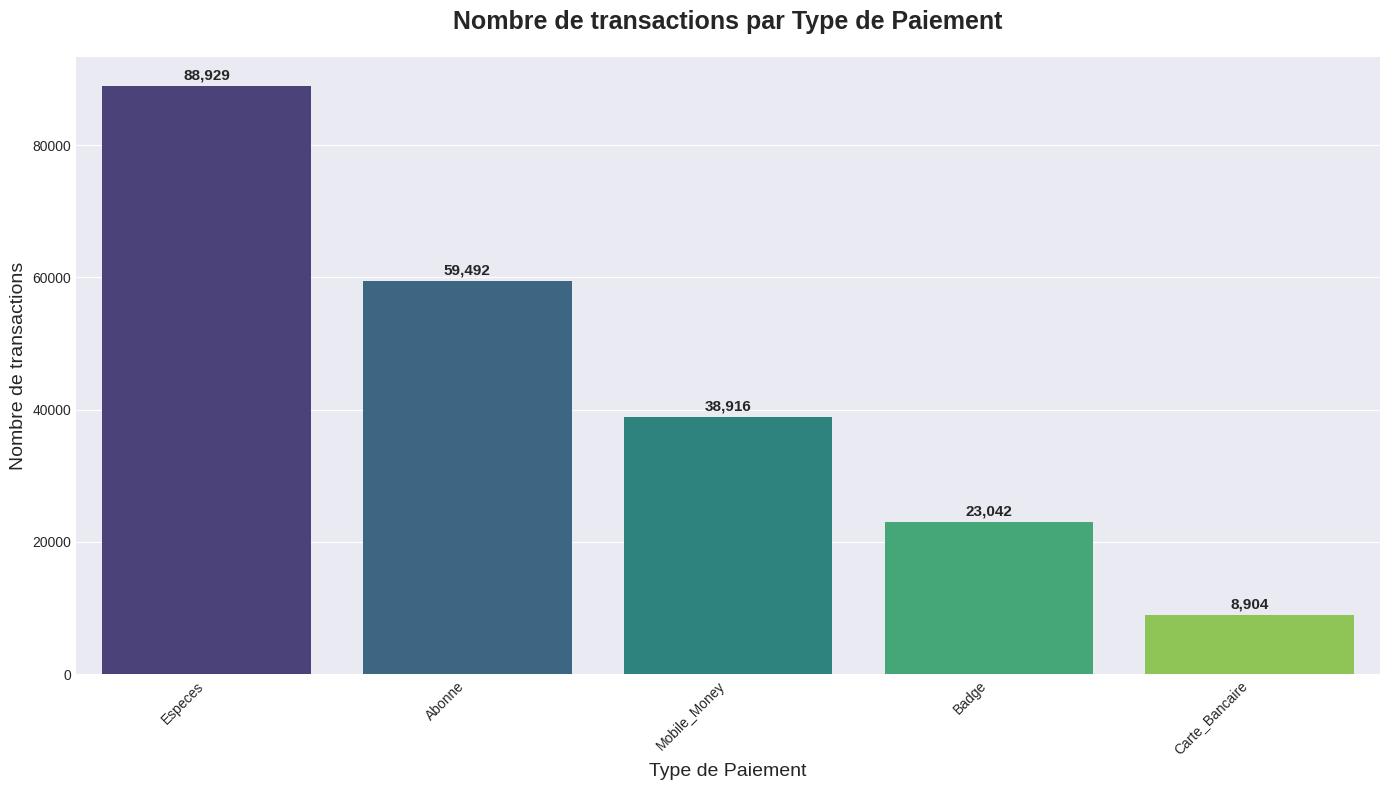

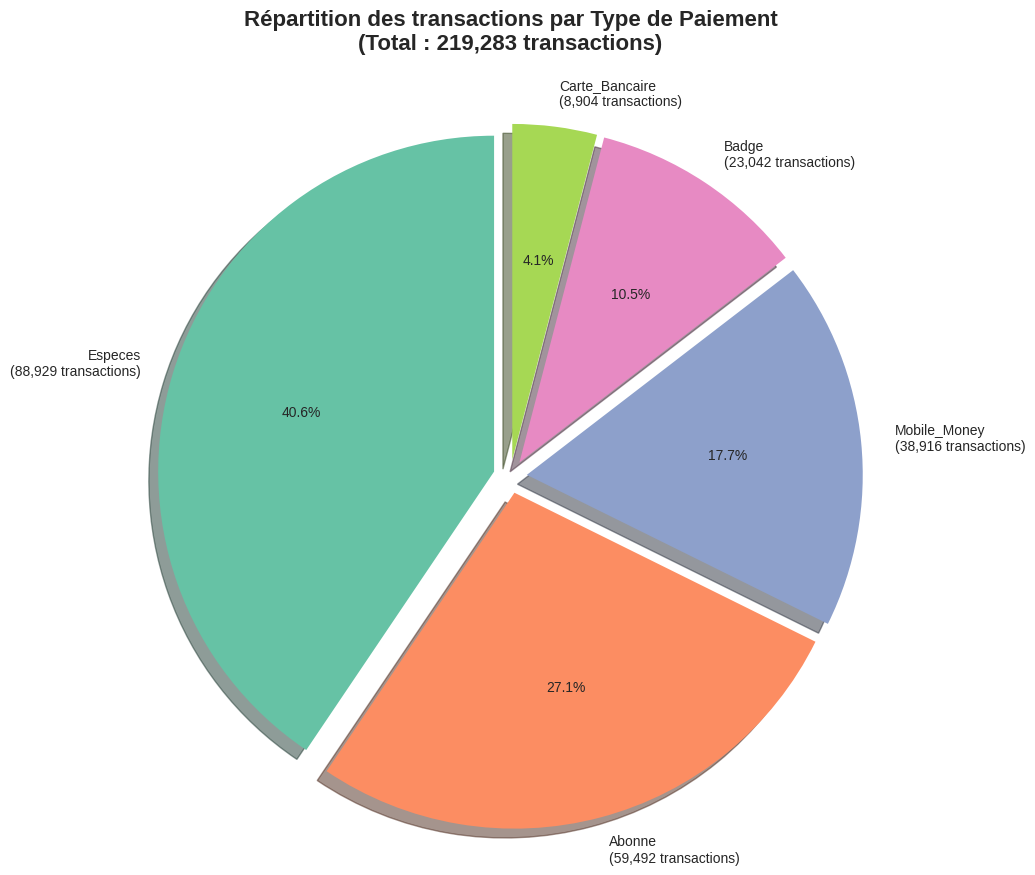

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données (si pas déjà fait)
df = pd.read_csv('donnees_synthetiques_tollxpress_benin_2023-2024.csv')

# ====================== VISUALISATION NOMBRE DE TRANSACTIONS PAR TYPE DE PAIEMENT ======================

plt.figure(figsize=(14, 8))

# Option 1 : Barplot classique (très lisible)
ax = sns.countplot(data=df,
                   x='Type_paiement',
                   order=df['Type_paiement'].value_counts().index,  # tri du plus fréquent au moins fréquent
                   palette='viridis')

plt.title('Nombre de transactions par Type de Paiement', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Type de Paiement', fontsize=14)
plt.ylabel('Nombre de transactions', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Ajout des valeurs sur chaque barre
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2., p.get_height() + 500),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 10))

# Pie chart avec pourcentages
counts = df['Type_paiement'].value_counts()
labels = [f"{idx}\n({val:,} transactions)" for idx, val in counts.items()]

plt.pie(counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.05] * len(counts),  # léger décalage pour chaque part
        shadow=True,
        colors=sns.color_palette('Set2'))

plt.title('Répartition des transactions par Type de Paiement\n(Total : {:,} transactions)'.format(len(df)),
          fontsize=16, fontweight='bold', pad=30)
plt.axis('equal')
plt.show()

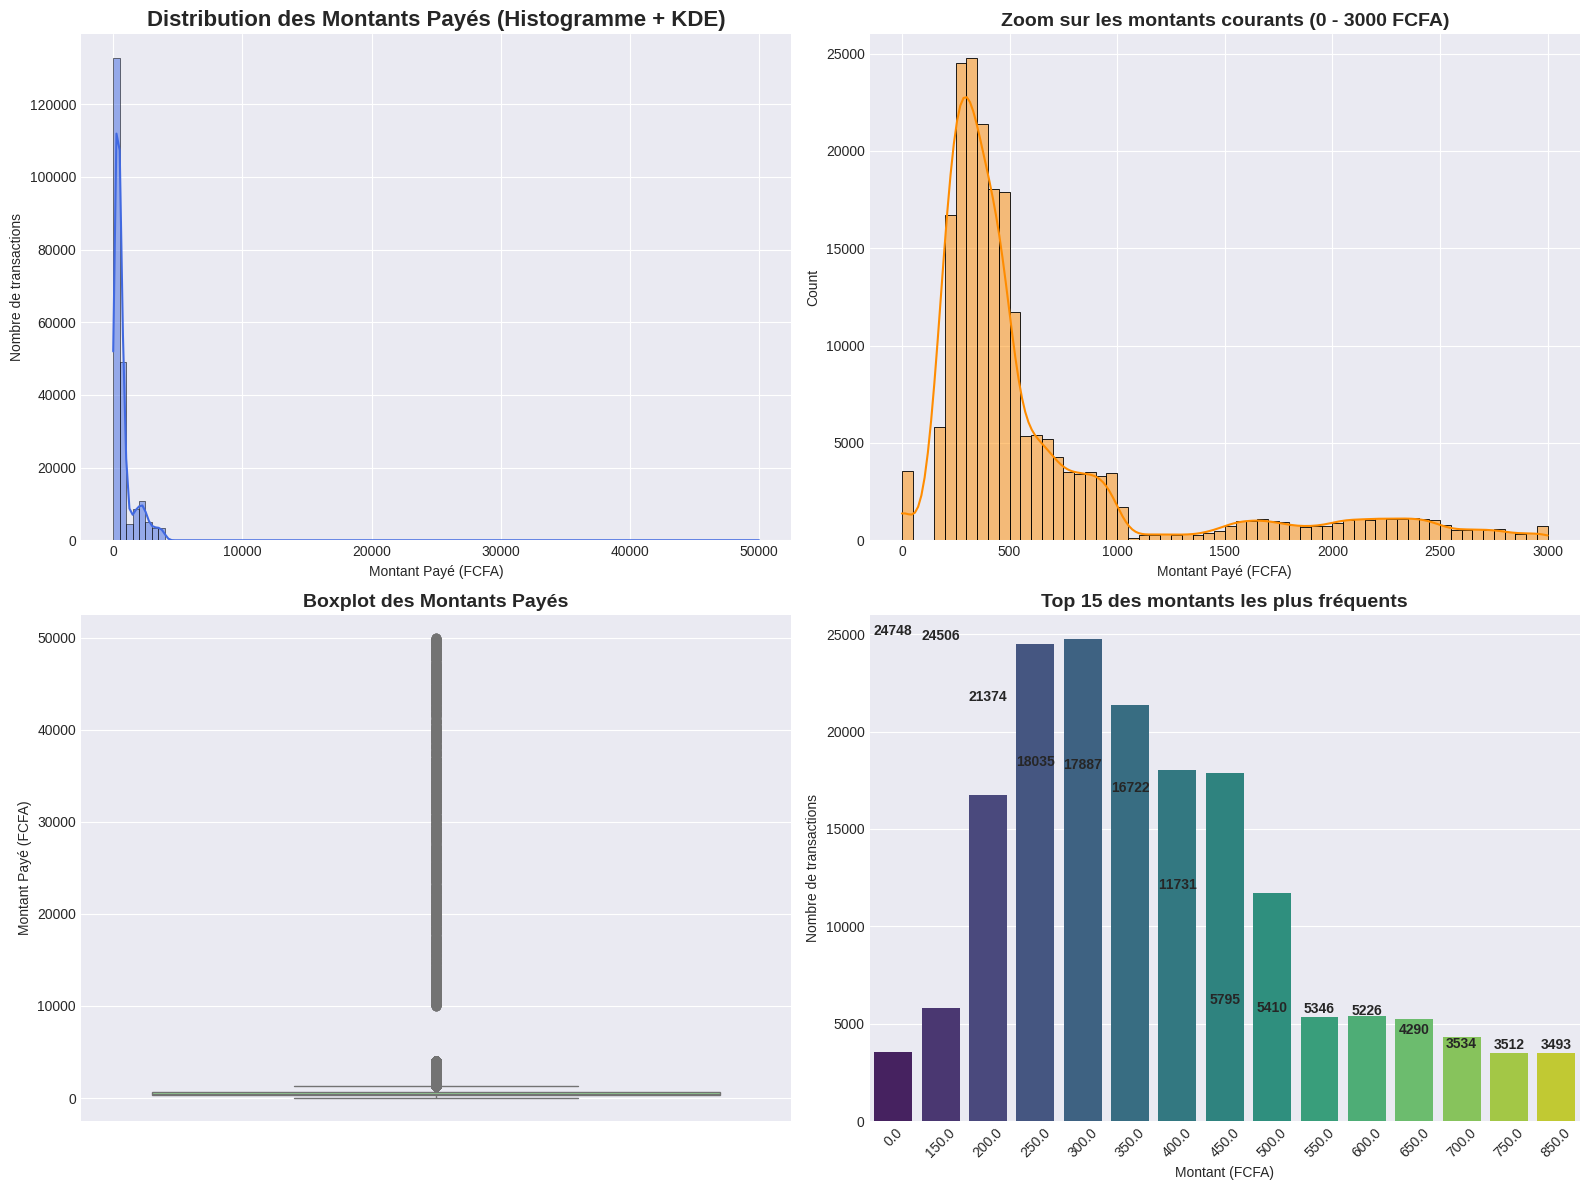

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Chargement des données
df = pd.read_csv('donnees_synthetiques_tollxpress_benin_2023-2024.csv')

# Nettoyage : on crée une colonne sans les valeurs négatives (anomalies/remboursements)
df['Montant_net'] = df['Montant_paye'].clip(lower=0)

# ====================== DISTRIBUTION DES MONTANTS PAYÉS ======================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogramme principal avec courbe de densité
sns.histplot(data=df, x='Montant_net', bins=100, kde=True, ax=axes[0,0], color='royalblue')
axes[0,0].set_title('Distribution des Montants Payés (Histogramme + KDE)', fontsize=16, fontweight='bold')
axes[0,0].set_xlabel('Montant Payé (FCFA)')
axes[0,0].set_ylabel('Nombre de transactions')

# 2. Histogramme avec focus sur les montants courants (0 à 3000 FCFA)
sns.histplot(data=df[df['Montant_net'] <= 3000], x='Montant_net', bins=60, kde=True,
             ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Zoom sur les montants courants (0 - 3000 FCFA)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Montant Payé (FCFA)')

# 3. Boxplot pour détecter les outliers
sns.boxplot(data=df, y='Montant_net', ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Boxplot des Montants Payés', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Montant Payé (FCFA)')

# 4. Top 15 des montants les plus fréquents (barplot)
top_montants = df['Montant_net'].value_counts().head(15).reset_index()
top_montants.columns = ['Montant', 'Nombre']
sns.barplot(data=top_montants, x='Montant', y='Nombre', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Top 15 des montants les plus fréquents', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Montant (FCFA)')
axes[1,1].set_ylabel('Nombre de transactions')
axes[1,1].tick_params(axis='x', rotation=45)

# Ajout des valeurs sur les barres
for i, v in enumerate(top_montants['Nombre']):
    axes[1,1].text(i, v + 200, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()